# 01 Feature Extraction

## Setup and imports

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

In [ ]:
requirements_path = "/content/drive/MyDrive/xai-project5/requirements.txt" if IN_COLAB else "./../../requirements.txt"

!pip install -r "{requirements_path}"

In [9]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
import open_clip
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm # Per la barra di avanzamento
import os
import io

In [ ]:
if IN_COLAB:
    save_dir = '/content/drive/MyDrive/xai-project5/results/01_feature_extraction'
else:
    save_dir = os.path.abspath(os.path.join('..', 'results', '01_feature_extraction'))

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'chest_embeddings_newModel.pt')
print(f"Salvataggio configurato su: {save_path}")

## Model and Dataset

In questa sezione, utilizziamo il modello **BioMedCLIP** (`microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224`) per estrarre gli embedding visivi dalle immagini mediche.

BioMedCLIP è un foundation model multimodale all'avanguardia, pre-addestrato su PMC-15M (un dataset su larga scala contenente 15 milioni di coppie immagine-testo estratte da PubMed Central). Rispetto ai modelli precedenti, offre rappresentazioni latenti significativamente più ricche e robuste, rendendolo ideale per il framework di discovery non supervisionata. Questo modello fornisce:

- **Vision Encoder (ViT-B/16)**: Elabora le immagini mediche (come le radiografie toraciche) e le trasforma in embedding vettoriali densi (dimensione 512).
- **Text Encoder (PubMedBERT)**: Sostituisce il text encoder standard con un modello linguistico specifico per il dominio biomedico, estendendo la context window fino a 256 token per catturare referti e descrizioni cliniche complesse.
- **Allineamento multimodale**: Gli embedding visivi e testuali sono proiettati nello stesso spazio latente condiviso. Questo permette un calcolo estremamente preciso della similarità coseno, passaggio fondamentale per il successivo allineamento semantico dei concetti scoperti dallo Sparse Autoencoder.

In [7]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

model_id = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

# Instantiate model, image transforms, and tokenizer via open_clip
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(model_id)
tokenizer = open_clip.get_tokenizer(model_id)

model = model.to(device)
model.eval() # è già pre-addestrato

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          

The dataset contains a set of chest X-ray images and their corresponding diagnostic reports, collected by Indiana University. It includes frontal or lateral chest X-ray images and the corresponding reports. Each radiology report includes four sections:
- The **Comparison** section contains prior patient information (e.g., previous medical examinations); 
- the **Indication** section details symptoms (e.g., hypoxia) or reasons for the examination (e.g., age); 
- the **Findings** section lists radiological observations; 
- the **Impression** section outlines the final diagnosis.

In [11]:
print("Scaricamento del dataset OpenI...")
dataset = load_dataset("ykumards/open-i", split="train")
df = dataset.to_pandas()

Scaricamento del dataset OpenI...


In [8]:
dataset[0]

{'uid': 1,
 'MeSH': 'normal',
 'Problems': 'normal',
 'image': 'Xray Chest PA and Lateral',
 'indication': 'Positive TB test',
 'comparison': 'None.',
 'findings': 'The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.',
 'impression': 'Normal chest x-XXXX.',
 'img_frontal': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xc0\x00\x0b\x08\x08\x00\t\xc0\x01\x01\x11\x00\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\

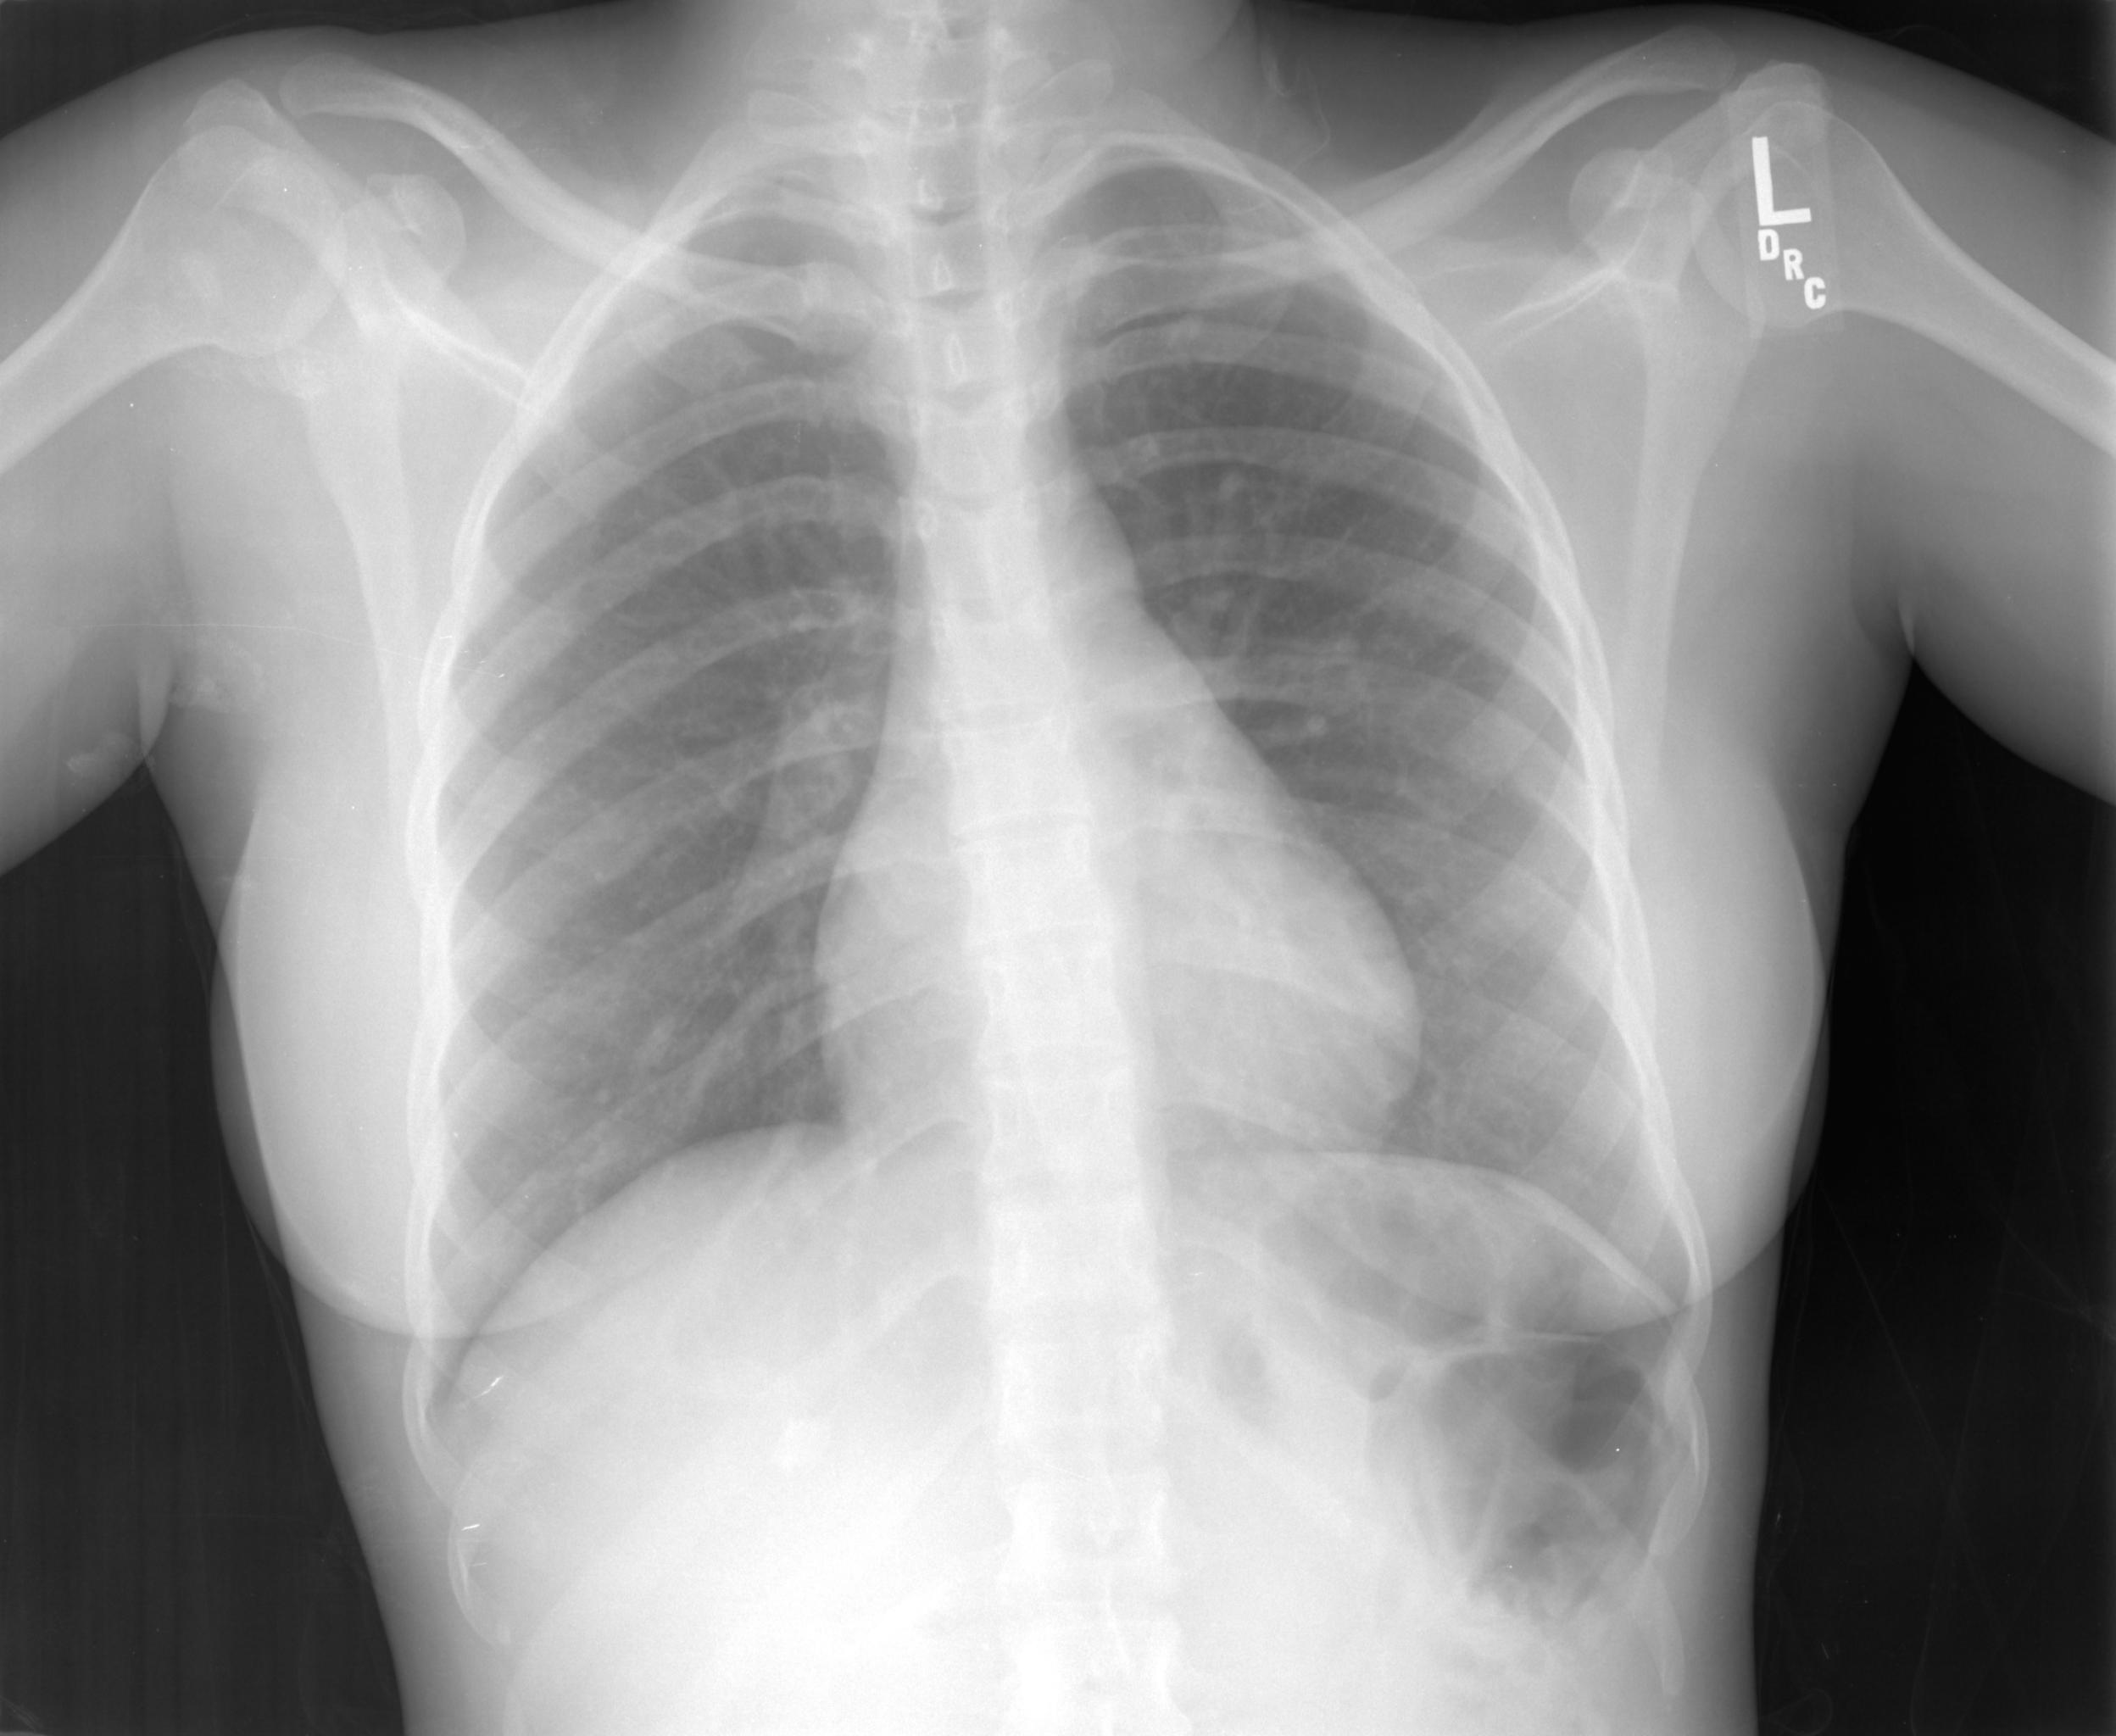

In [10]:
image_bytes = dataset[0]['img_frontal'] #img_frontal and img_lateral are raw bytes
image = Image.open(io.BytesIO(image_bytes)) #We use BytesIO to manage this bytes
display(image)

Per garantire la correttezza semantica e allineare un'immagine alla volta con la ground truth usiamo solo img_frontal

## Extraction embedding and visualization

Gli embedding estratti sono **normalizzati L2**, garantendo che ogni vettore abbia norma unitaria. Questo è fondamentale per:
1. Stabilizzare il training dello Sparse Autoencoder
2. Semplificare il calcolo della similarità coseno (che diventa una semplice moltiplicazione matriciale)
3. Interpretare semanticamente i neuroni latenti del SAE

In [13]:
all_embeddings = []
all_reports = []

print("Estrazione embedding visivi in corso....")

with torch.no_grad():
    for item in tqdm(dataset):
        try:
            image_bytes = item['img_frontal'] #img_frontal and img_lateral are raw bytes

            if image_bytes is None or len(image_bytes) == 0:
                print(f"Campione con ID {item.get('uid')} ha un'immagine vuota!")
                continue
            if not image_bytes or not isinstance(image_bytes, bytes):
                continue
            
            image = Image.open(io.BytesIO(image_bytes)).convert("RGB") #We use BytesIO to manage this bytes

            image_tensor = preprocess_val(image).unsqueeze(0).to(device)
            vision_features = model.encode_image(image_tensor) # dim: (batch_size, embedding_dimension)
            vision_embeddings = F.normalize(vision_features, p=2, dim=1)
            
            # Building the ground truth
            findings = item.get('findings', '')
            impression = item.get('impression', '')
            
            if findings is None: findings = ""
            if impression is None: impression = ""
            
            full_report = f"{findings} {impression}".strip()
        
            if len(full_report) < 10:
                continue
                
            all_embeddings.append(vision_embeddings.cpu())
            all_reports.append(full_report)

        except Exception as e:
            print(f"Errore durante l'elaborazione di un campione: {e}")
            continue

if all_embeddings:
    final_embeddings = torch.cat(all_embeddings, dim=0)
    
    dataset_dict = {
        "embeddings": final_embeddings,
        "reports": all_reports 
    }
    
    # Creation of directories and saving the results
    save_path = os.path.join(save_dir, "biomedclip_openi_with_reports.pt")
    torch.save(dataset_dict, save_path)
    print(f"\nSalvataggio completato con successo in: {save_path}")
    print(f"Totale campioni elaborati e allineati: {len(all_reports)}")
    print(f"Shape del tensore visivo: {final_embeddings.shape}")
else:
    print("\nNessun dato valido estratto. Controllare il caricamento del dataset.")

Estrazione embedding visivi in corso....


  2%|▏         | 79/3851 [00:03<02:03, 30.53it/s]

Campione con ID 74 ha un'immagine vuota!


  2%|▏         | 83/3851 [00:03<01:55, 32.68it/s]

Campione con ID 81 ha un'immagine vuota!


...

Campione con ID 3950 ha un'immagine vuota!


 99%|█████████▉| 3819/3851 [02:15<00:01, 29.41it/s]

Campione con ID 3963 ha un'immagine vuota!


100%|██████████| 3851/3851 [02:16<00:00, 28.21it/s]



Salvataggio completato con successo in: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/01_feature_extraction/biomedclip_openi_with_reports2.pt
Totale campioni elaborati e allineati: 3666
Shape del tensore visivo: torch.Size([3666, 512])


In [19]:
embeddings = dataset_dict["embeddings"]
reports = dataset_dict["reports"]

print("--- Inspecting the first 2 elements ---")
for i in range(2):
    print(f"Item {i+1}:")
    
    # Print the text report
    print(f"  Report: {reports[i]}")
    
    # Print info about the corresponding embedding
    emb = embeddings[i]
    if hasattr(emb, 'shape'):
        print(f"  Embedding Shape: {emb.shape}")
    
    # Print just the first 5 values
    print(f"  Embedding (first 5 values): {emb[:5]}")


--- Inspecting the first 2 elements ---
Item 1:
  Report: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax. Normal chest x-XXXX.
  Embedding Shape: torch.Size([512])
  Embedding (first 5 values): tensor([-0.0746, -0.0400, -0.2510, -0.0141, -0.0297])
Item 2:
  Report: Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX. No acute pulmonary findings.
  Embedding Shape: torch.Size([512])
  Embedding (first 5 values): tensor([-0.0494, -0.0461, -0.2732, -0.0070, -0.0148])
